# ![Machine Learning Lab](banner.jpg)

# Laboratorio 7 - Actividad

## Instrucciones generales

1. Esta actividad es de carácter individual. No se permite entregar la actividad después de la fecha establecida.
2. Al responder las preguntas de las actividades, por favor marquen las respuestas con la sección a la que corresponden, por ejemplo: `## 1.1 Carga de datos`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor asegurarse de que el notebook entregado tenga todas las celdas ejecutadas correctamente.
4. Por favor, nombren el archivo de acuerdo con el siguiente formato `{email}_lab7.ipynb`.
5. Si tienen alguna duda, pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams.

---

## Objetivos

1. Construir y entrenar un Perceptrón Multicapa (MLP) para clasificación multiclase.
2. Implementar el mismo modelo en dos frameworks: **PyTorch** y **TensorFlow/Keras**.
3. Evaluar y comparar el desempeño de ambos modelos.

---

En esta ocasión trabajaremos con el dataset **Blood Cell Anomaly Detection 2025**, que contiene 5,880 registros de células sanguíneas con 36 características morfológicas, clínicas y de adquisición. El objetivo es clasificar cada registro en uno de los **19 tipos de célula** disponibles.

Dataset: [Blood Cell Anomaly Detection 2025](https://www.kaggle.com/datasets/alitaqishah/blood-cell-anomaly-detection-2025)

---

## Instrucciones

### 1. Carga y exploración de datos (10%)

1. Descarga el archivo `blood_cell_anomaly_detection.csv` desde Kaggle.
2. Carga el CSV en un DataFrame y muestra las primeras filas.
3. Identifica la columna objetivo (`cell_type`) y muestra la distribución de las 19 clases.
4. ¿Cuántas características numéricas y categóricas tiene el dataset? ¿Hay valores faltantes?

---

### 2. Preprocesamiento de datos (20%)

Las siguientes columnas **no deben usarse** como features: `anomaly_label`, `disease_category`, `cytodiffusion_anomaly_score`, `cytodiffusion_classification_confidence`, `labeller_confidence_score`.

1. Elimina las columnas mencionadas y el identificador (`cell_id`).
2. Normaliza las features numéricas (escalar al rango [0,1] o estandarizar).
3. Aplica **one-hot encoding** a las features categóricas y combínalas con las numéricas.
4. Codifica la columna objetivo (`cell_type`) como valores numéricos.
5. Divide los datos en conjunto de entrenamiento (80%) y prueba (20%). Utiliza `random_state = 42`

---

### 3. MLP con PyTorch (30%)

1. Convierte los datos de entrenamiento y prueba a tensores de PyTorch y crea DataLoaders.
2. Construye un MLP usando `nn.Module` con al menos 2 capas ocultas y activación ReLU.
3. ¿Cuántos parámetros tiene la red? Muestra la cantidad de parametros por cada capa.
4. Entrena el modelo por al menos 20 épocas. Grafica la curva de pérdida.
5. Evalúa el modelo en el conjunto de prueba y reporta la precisión (accuracy).

---

### 4. MLP con TensorFlow/Keras (30%)

1. Construye un MLP equivalente al anterior usando la API Sequential de Keras.
2. Compila el modelo con el optimizador y función de pérdida adecuados.
3. Entrena el modelo por al menos 20 épocas. Grafica la curva de pérdida.
4. Evalúa el modelo en el conjunto de prueba y reporta la precisión (accuracy).

---

### 5. Comparación de resultados (10%)

1. Genera la matriz de confusión para los modelos MLP.
2. ¿Cuáles tipos de célula son más difíciles de clasificar? ¿Son los mismos en ambos modelos?
3. Compara la precisión obtenida con PyTorch vs TensorFlow.

---


### 1. Carga y exploración de datos (10%)

1. Descarga el archivo `blood_cell_anomaly_detection.csv` desde Kaggle.
2. Carga el CSV en un DataFrame y muestra las primeras filas.
3. Identifica la columna objetivo (`cell_type`) y muestra la distribución de las 19 clases.
4. ¿Cuántas características numéricas y categóricas tiene el dataset? ¿Hay valores faltantes?


In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import torch

In [90]:
# cargar el csv y mostrar las primeras filas
cell_anomaly_df = pd.read_csv('datasets/blood_cell_anomaly_detection.csv')
cell_anomaly_df.head()

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


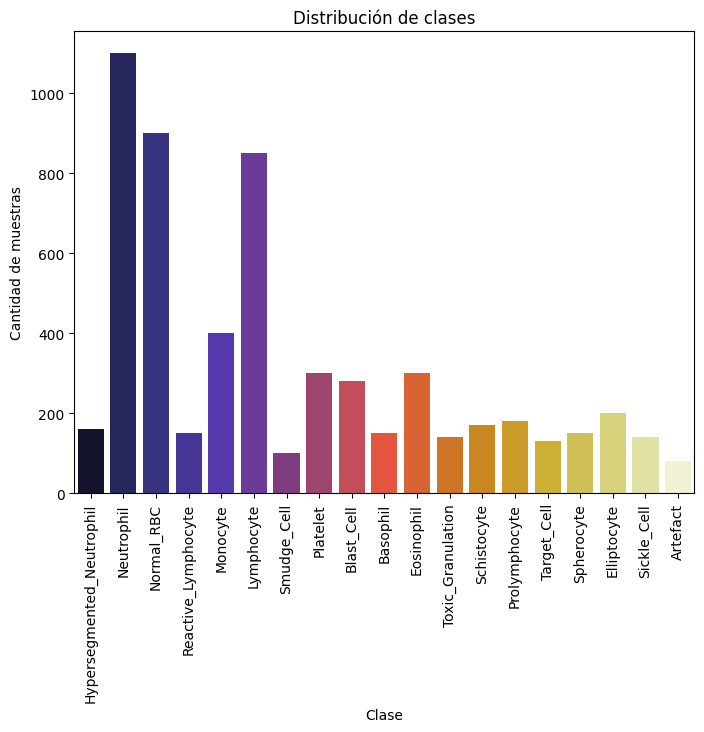

In [91]:
# graficar la distribución de las clases
plt.figure(figsize=(8, 6))
seaborn.countplot(x='cell_type', data=cell_anomaly_df, palette='CMRmap', hue='cell_type')
plt.title('Distribución de clases')
plt.xlabel('Clase')
plt.ylabel('Cantidad de muestras')
plt.xticks(rotation=90)
plt.show()

In [92]:
# excluir el id para
cell_anomaly_df = cell_anomaly_df.drop(columns=['cell_id'])
# identificar caracteristicas numéricas y categóricas 
numerical_features = cell_anomaly_df.select_dtypes(include=['number']).columns
categorical_features = cell_anomaly_df.select_dtypes(include=['object', 'str']).columns

print("Características numéricas:", numerical_features)
print("Características categóricas:", categorical_features)

Características numéricas: Index(['anomaly_label', 'cell_diameter_um', 'nucleus_area_pct',
       'chromatin_density', 'cytoplasm_ratio', 'circularity', 'eccentricity',
       'granularity_score', 'lobularity_score', 'membrane_smoothness',
       'cell_area_px', 'perimeter_px', 'mean_r', 'mean_g', 'mean_b',
       'stain_intensity', 'wbc_count_per_ul', 'rbc_count_millions_per_ul',
       'hemoglobin_g_dl', 'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl',
       'mchc_g_dl', 'magnification_x', 'image_resolution_px',
       'cytodiffusion_anomaly_score',
       'cytodiffusion_classification_confidence', 'labeller_confidence_score'],
      dtype='str')
Características categóricas: Index(['cell_type', 'disease_category', 'patient_age_group', 'patient_sex',
       'dataset_source', 'staining_protocol', 'microscope_model'],
      dtype='str')


In [93]:
# valores faltantes
missing_values = cell_anomaly_df.isnull().sum()
print("Valores faltantes por columna:")
print(missing_values)

Valores faltantes por columna:
cell_type                                  0
anomaly_label                              0
disease_category                           0
cell_diameter_um                           0
nucleus_area_pct                           0
chromatin_density                          0
cytoplasm_ratio                            0
circularity                                0
eccentricity                               0
granularity_score                          0
lobularity_score                           0
membrane_smoothness                        0
cell_area_px                               0
perimeter_px                               0
mean_r                                     0
mean_g                                     0
mean_b                                     0
stain_intensity                            0
patient_age_group                          0
patient_sex                                0
wbc_count_per_ul                           0
rbc_count_millions_per_u

El dataset cuenta con 35 características (excluyendo el identificador `cell_id`), de las cuales 30 son numéricas y 5 son categóricas. No se reportan valores faltantes en el dataset.

### 2. Preprocesamiento de datos (20%)

Las siguientes columnas **no deben usarse** como features: `anomaly_label`, `disease_category`, `cytodiffusion_anomaly_score`, `cytodiffusion_classification_confidence`, `labeller_confidence_score`.

1. Elimina las columnas mencionadas y el identificador (`cell_id`).
2. Normaliza las features numéricas (escalar al rango [0,1] o estandarizar).
3. Aplica **one-hot encoding** a las features categóricas y combínalas con las numéricas.
4. Codifica la columna objetivo (`cell_type`) como valores numéricos.
5. Divide los datos en conjunto de entrenamiento (80%) y prueba (20%). Utiliza `random_state = 42`

In [94]:
# eliminar columnas no relevantes - el cell_id ya fue eliminado
columns_to_drop = ['anomaly_label', 'disease_category', 'cytodiffusion_anomaly_score', 'cytodiffusion_classification_confidence', 'labeller_confidence_score']
cell_anomaly_df = cell_anomaly_df.drop(columns=columns_to_drop)

# obtener nuevamente las características numéricas y categóricas después de la eliminación de columnas
numerical_features = cell_anomaly_df.select_dtypes(include=['number']).columns
categorical_features = cell_anomaly_df.select_dtypes(include=['object', 'str']).columns

# sacar cell_type de las características categóricas para no codificarla
categorical_features = categorical_features.drop('cell_type')

# estandarizar las características numéricas
scaler = StandardScaler()
cell_anomaly_df[numerical_features] = scaler.fit_transform(cell_anomaly_df[numerical_features])

# aplicar one-hot encoding a las características categóricas
encoder = OneHotEncoder()
encoded_categorical = encoder.fit_transform(cell_anomaly_df[categorical_features])
encoded_categorical_df = pd.DataFrame(encoded_categorical.toarray(), columns=encoder.get_feature_names_out(categorical_features))
# combinar las características numéricas estandarizadas con las características categóricas codificadas
cell_anomaly_df = pd.concat([cell_anomaly_df[numerical_features].reset_index(drop=True), encoded_categorical_df.reset_index(drop=True), cell_anomaly_df['cell_type'].reset_index(drop=True)], axis=1)

# codificar la columna objetivo 'cell_type' como etiquetas numéricas
label_encoder = LabelEncoder()
cell_anomaly_df['cell_type'] = label_encoder.fit_transform(cell_anomaly_df['cell_type'])

# dividir los datos en entrenamiento y prueba 
X = cell_anomaly_df.drop(columns=['cell_type'])
y = cell_anomaly_df['cell_type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [95]:
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)
print("Codificación de clases:", label_encoder.classes_)

Tamaño del conjunto de entrenamiento: (4704, 38)
Tamaño del conjunto de prueba: (1176, 38)
Codificación de clases: ['Artefact' 'Basophil' 'Blast_Cell' 'Elliptocyte' 'Eosinophil'
 'Hypersegmented_Neutrophil' 'Lymphocyte' 'Monocyte' 'Neutrophil'
 'Normal_RBC' 'Platelet' 'Prolymphocyte' 'Reactive_Lymphocyte'
 'Schistocyte' 'Sickle_Cell' 'Smudge_Cell' 'Spherocyte' 'Target_Cell'
 'Toxic_Granulation']


### 3. MLP con PyTorch (30%)

1. Convierte los datos de entrenamiento y prueba a tensores de PyTorch y crea DataLoaders.
2. Construye un MLP usando `nn.Module` con al menos 2 capas ocultas y activación ReLU.
3. ¿Cuántos parámetros tiene la red? Muestra la cantidad de parametros por cada capa.
4. Entrena el modelo por al menos 20 épocas. Grafica la curva de pérdida.
5. Evalúa el modelo en el conjunto de prueba y reporta la precisión (accuracy).

In [ ]:
# convertir a tensores de PyTorch
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)